## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [13]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 30.0          # Natural frequency (rad/s)
w_p = 2*w_0*1.0      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
F_p = 0.05      # Amplitude of the w_p driving
Qual = 10.0
gamma = 0*10*.05*1.0              # Nonlinearity coefficient (Duffing term)

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 300.0             # Temperature (K)
D = 0* k_B * T       # Noise strength

args = (M, w_0, w_p,Qual, gamma, F_p)



# Simulation Parameters
t0 = 0.0  
num_periods = 11# Start time
t1 = num_periods*((2*jnp.pi)/w_0)
dt0 = 0.0001
ts_dim = jnp.linspace(t0, t1, 100000)

t1_nonDim = num_periods*2*jnp.pi  # End time
ts_nonDim = jnp.linspace(t0, t1_nonDim, 100000)

# Initial Conditions
x0 = -.1               # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])


rtol=1e-6
atol=1e-6

In [14]:
t1_nonDim

69.11503837897544

In [15]:
def parameteric_ramp(t):
    tc = 3.0  # time when amplitude reaches ~99% of max
    ramp = 0.5 * (1 + jnp.tanh(4 * (t - tc/2) / tc))  # smooth transition from 0 to 1
    return  1


In [16]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    M, w_0, w_p, Qual, gamma, F_p = args
    x, v = state
    dxdt = v
    dvdt =  -w_0/Qual * v - w_0**2 * (1 - parameteric_ramp(t)*F_p/M * jnp.cos(w_p * t)) * x - gamma * x**3 
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    return 0*jnp.array([0.0, D])

In [17]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

In [18]:

terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# Define the time points for sampling

saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    stepsize_controller=PIDController(rtol=rtol, atol=atol),
)
sde_samples_x = solution_x.ys[:, :N]


100.00%|##########| [00:00<00:00, 170.46%/s]


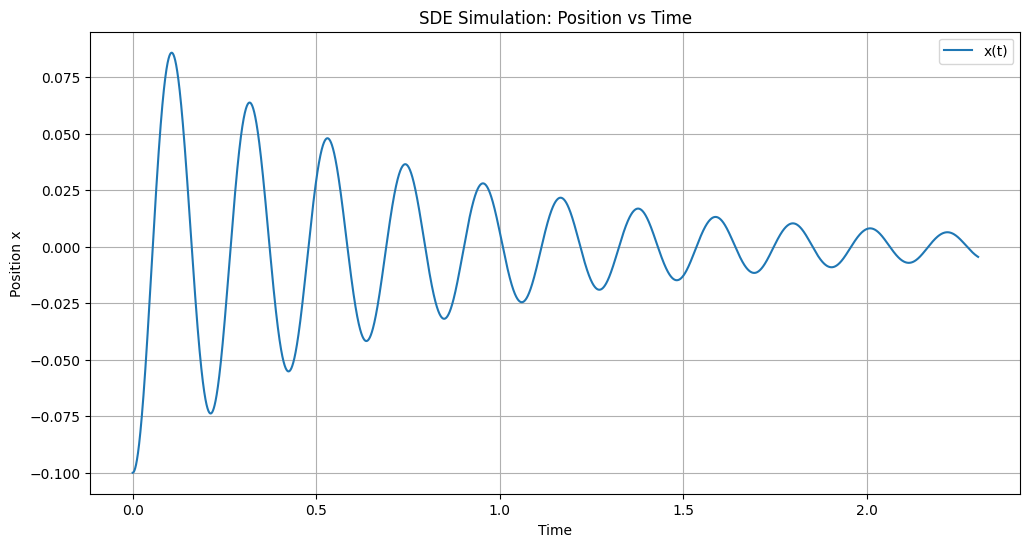

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(ts_dim, sde_samples_x[:, 0], label='x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [20]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_nonDim_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    M, w_0, w_p, Qual, gamma, F_p = args
    x, v = state
    dxdt = v
    dvdt =  -1/Qual * v - (1 - parameteric_ramp(t)*F_p/1 * jnp.cos(2 * t)) * x - gamma * x**3 
    return jnp.array([dxdt, dvdt])

def diffusion_x_nonDim_fn(t, state, args):
    """
    Diffusion 
    """
    return 0*jnp.array([0.0, D])

In [21]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)
brownian_motion_nonDim = diffrax.VirtualBrownianTree(
    t0, t1_nonDim, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)


terms_x_nonDim = MultiTerm(ODETerm(drift_x_nonDim_fn), ControlTerm(diffusion_x_nonDim_fn, brownian_motion_nonDim))
# Define the time points for sampling

saveat = diffrax.SaveAt(ts=ts_nonDim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x_nonDim,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1_nonDim,
    dt0=dt0,
    y0=y0_x,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
    stepsize_controller=PIDController(rtol=rtol, atol=atol),
)
sde_samples_x_nonDim = solution_x.ys[:, :N]


100.00%|##########| [00:00<00:00, 442.98%/s]


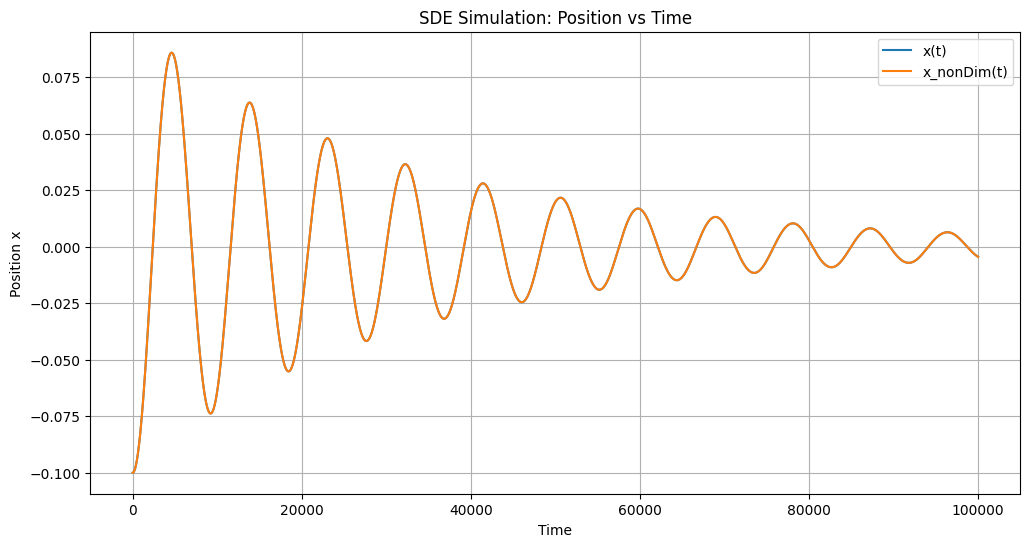

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(sde_samples_x[:, 0], label='x(t)')
plt.plot(sde_samples_x_nonDim[:, 0], label='x_nonDim(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()